## 1. Setup Lingkungan

Import library utama, konfigurasi path dataset Kaggle, dan tampilkan isi direktori input.

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FASE 1: PERSIAPAN DAN SETUP")
print("="*80)

# Cek isi /kaggle/input untuk memastikan nama folder dataset
print("Isi /kaggle/input:")
print(os.listdir("/kaggle/input"))

# GANTI sesuai output di atas jika perlu
dataset_path = "/kaggle/input/datasets/crawford/qureai-headct"  

working_path = "/kaggle/working/ich_project"
os.makedirs(working_path, exist_ok=True)

print(f"\nDataset Path: {dataset_path}")
print(f"Working Path: {working_path}")


FASE 1: PERSIAPAN DAN SETUP
Isi /kaggle/input:
['datasets']

Dataset Path: /kaggle/input/datasets/crawford/qureai-headct
Working Path: /kaggle/working/ich_project


## 2. DICOM Parsing & Metadata Studi

Kelas `CQ500Dataset` membaca semua file DICOM dari direktori dataset dan membangun DataFrame metadata: `study_id`, `num_slices`, `dicom_files`, dan label subtipe ICH.

In [2]:
class CQ500Dataset:

    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.df = self._build_metadata()

    def _build_metadata(self):

        study_dict = {}

        for dcm_path in self.dataset_path.rglob("*.dcm"):

            # Ambil folder seperti:
            # "CQ500CT156 CQ500CT156"
            raw_folder = dcm_path.parts[-4]

            # Ambil hanya bagian pertama (hapus duplikasi)
            clean_id = raw_folder.split()[0]

            study_dict.setdefault(clean_id, []).append(dcm_path)

        data = []

        for study_id, slices in study_dict.items():
            data.append({
                "study_id": study_id,
                "num_slices": len(slices),
                "dicom_files": sorted(
                    [str(p.relative_to(self.dataset_path)) for p in slices]
                )
            })

        return pd.DataFrame(data)


### Instansiasi Dataset & Preview

Membuat objek `CQ500Dataset` dan menampilkan jumlah studi serta 5 baris pertama metadata.

In [3]:
dataset = CQ500Dataset(dataset_path)

print("Total studies:", len(dataset.df))
print(dataset.df.head())


Total studies: 473
     study_id  num_slices                                        dicom_files
0  CQ500CT156         191  [qct03/CQ500CT156 CQ500CT156/Unknown Study/CT ...
1  CQ500CT144         320  [qct02/CQ500CT144 CQ500CT144/Unknown Study/CT ...
2   CQ500CT15         252  [qct03/CQ500CT15 CQ500CT15/Unknown Study/CT 55...
3  CQ500CT162         756  [qct03/CQ500CT162 CQ500CT162/Unknown Study/CT ...
4  CQ500CT158         581  [qct03/CQ500CT158 CQ500CT158/Unknown Study/CT ...


### Tampilkan DataFrame

Melihat 5 baris pertama DataFrame metadata dataset.

In [4]:
dataset.df.head()

,study_id,num_slices,dicom_files
0,CQ500CT156,191,[qct03/CQ500CT156 CQ500CT156/Unknown Study/CT ...
1,CQ500CT144,320,[qct02/CQ500CT144 CQ500CT144/Unknown Study/CT ...
2,CQ500CT15,252,[qct03/CQ500CT15 CQ500CT15/Unknown Study/CT 55...
3,CQ500CT162,756,[qct03/CQ500CT162 CQ500CT162/Unknown Study/CT ...
4,CQ500CT158,581,[qct03/CQ500CT158 CQ500CT158/Unknown Study/CT ...


## 3. Load Label CSV (Reads)

Memuat file `reads.csv` dari dataset QureAI yang berisi penilaian 3 radiolog (R1, R2, R3) untuk ICH dan subtipenya per studi.

In [6]:
import pandas as pd

labels_df = pd.read_csv("/kaggle/input/datasets/crawford/qureai-headct/reads.csv")

print("Shape:", labels_df.shape)
print(labels_df.columns)


Shape: (491, 44)
Index(['name', 'Category', 'R1:ICH', 'R1:IPH', 'R1:IVH', 'R1:SDH', 'R1:EDH',
       'R1:SAH', 'R1:BleedLocation-Left', 'R1:BleedLocation-Right',
       'R1:ChronicBleed', 'R1:Fracture', 'R1:CalvarialFracture',
       'R1:OtherFracture', 'R1:MassEffect', 'R1:MidlineShift', 'R2:ICH',
       'R2:IPH', 'R2:IVH', 'R2:SDH', 'R2:EDH', 'R2:SAH',
       'R2:BleedLocation-Left', 'R2:BleedLocation-Right', 'R2:ChronicBleed',
       'R2:Fracture', 'R2:CalvarialFracture', 'R2:OtherFracture',
       'R2:MassEffect', 'R2:MidlineShift', 'R3:ICH', 'R3:IPH', 'R3:IVH',
       'R3:SDH', 'R3:EDH', 'R3:SAH', 'R3:BleedLocation-Left',
       'R3:BleedLocation-Right', 'R3:ChronicBleed', 'R3:Fracture',
       'R3:CalvarialFracture', 'R3:OtherFracture', 'R3:MassEffect',
       'R3:MidlineShift'],
      dtype='object')


### Preview Label CSV

Melihat 5 baris pertama dari `reads.csv` untuk memahami struktur data anotasi.

In [7]:
labels_df.head()

,name,Category,R1:ICH,R1:IPH,R1:IVH,R1:SDH,R1:EDH,R1:SAH,R1:BleedLocation-Left,R1:BleedLocation-Right,...,R3:EDH,R3:SAH,R3:BleedLocation-Left,R3:BleedLocation-Right,R3:ChronicBleed,R3:Fracture,R3:CalvarialFracture,R3:OtherFracture,R3:MassEffect,R3:MidlineShift
0,CQ500-CT-427,B2,1,1,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,1,0
1,CQ500-CT-181,B2,1,1,0,1,0,1,1,0,...,1,1,1,0,0,1,1,0,1,1
2,CQ500-CT-99,B1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CQ500-CT-47,B1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CQ500-CT-195,B1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Distribusi Jumlah Slice per Studi

Histogram untuk melihat rentang dan persebaran jumlah slice antar studi.

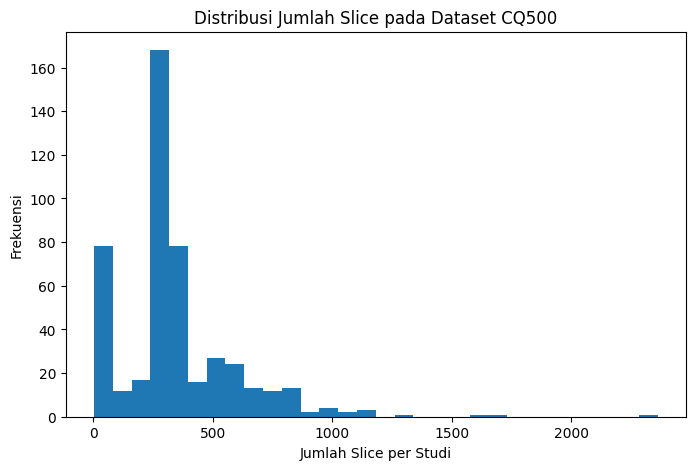

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(dataset.df["num_slices"], bins=30)
plt.xlabel("Jumlah Slice per Studi")
plt.ylabel("Frekuensi")
plt.title("Distribusi Jumlah Slice pada Dataset CQ500")
plt.show()

## 4. Konstruksi Label via Majority Voting

Membuat label biner untuk `Any_ICH` dan setiap subtipe (IPH, IVH, SDH, EDH, SAH) menggunakan majority voting dari ketiga radiolog.

In [9]:
labels_df.columns = labels_df.columns.str.strip()

print("Total studi di CSV:", len(labels_df))


# --------------------------------------------------------------------------
# 1. Definisikan subtipe
# --------------------------------------------------------------------------

subtypes = ["ICH", "IPH", "IVH", "SDH", "EDH", "SAH"]


# --------------------------------------------------------------------------
# 2. Majority voting: positif jika ≥2 radiolog memberi label 1
# --------------------------------------------------------------------------

for subtype in subtypes:
    
    r1 = f"R1:{subtype}"
    r2 = f"R2:{subtype}"
    r3 = f"R3:{subtype}"
    
    labels_df[subtype] = (
        labels_df[[r1, r2, r3]].sum(axis=1) >= 2
    ).astype(int)


# --------------------------------------------------------------------------
# 3. Definisi Any-ICH (Persamaan 4.2)
# y_any = max(IPH, IVH, SDH, EDH, SAH)
# --------------------------------------------------------------------------

labels_df["Any_ICH"] = labels_df[
    ["IPH", "IVH", "SDH", "EDH", "SAH"]
].max(axis=1)


# --------------------------------------------------------------------------
# 4. Sinkronisasi ID dengan folder DICOM
# --------------------------------------------------------------------------

# Ubah format dataset ID menjadi format CSV
dataset.df["study_id_csv_format"] = dataset.df["study_id"].apply(
    lambda x: x.replace("CQ500CT", "CQ500-CT-")
)

# Pastikan kolom name di CSV bersih
labels_df["name_clean"] = labels_df["name"].str.strip()

# Merge
dataset.df = dataset.df.merge(
    labels_df,
    left_on="study_id_csv_format",
    right_on="name_clean",
    how="inner"
)

print("Jumlah studi setelah merge:", len(dataset.df))


# --------------------------------------------------------------------------
# 5. Verifikasi distribusi kelas
# --------------------------------------------------------------------------

print("\nDistribusi Any-ICH:")
print(dataset.df["Any_ICH"].value_counts())

print("\nDistribusi Subtipe:")
for subtype in ["IPH","IVH","SDH","EDH","SAH"]:
    print(f"{subtype}: {dataset.df[subtype].sum()}")

Total studi di CSV: 491
Jumlah studi setelah merge: 473

Distribusi Any-ICH:
Any_ICH
0    282
1    191
Name: count, dtype: int64

Distribusi Subtipe:
IPH: 129
IVH: 26
SDH: 49
EDH: 12
SAH: 57


## 5. Visualisasi Kesepakatan Radiolog

Histogram tingkat kesepakatan antar radiolog untuk menilai konsistensi anotasi.

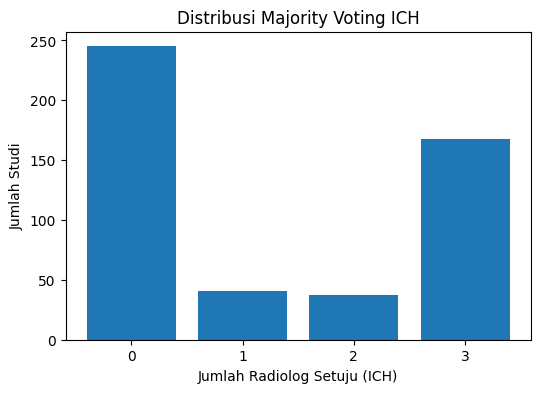

In [10]:
import matplotlib.pyplot as plt

agreement_counts = []

for idx, row in labels_df.iterrows():
    votes = row[["R1:ICH","R2:ICH","R3:ICH"]].sum()
    agreement_counts.append(votes)

plt.figure(figsize=(6,4))
plt.hist(agreement_counts, bins=[0,1,2,3,4], align="left", rwidth=0.8)
plt.xlabel("Jumlah Radiolog Setuju (ICH)")
plt.ylabel("Jumlah Studi")
plt.title("Distribusi Majority Voting ICH")
plt.xticks([0,1,2,3])
plt.show()


### Simpan Labeled Metadata

Menyimpan DataFrame yang sudah memiliki label hasil majority voting ke file `.pkl`.

In [11]:

save_dir = "/kaggle/working/cache"
os.makedirs(save_dir, exist_ok=True)

labeled_metadata_path = os.path.join(save_dir, "cq500_labeled_metadata.pkl")

with open(labeled_metadata_path, "wb") as f:
    pickle.dump(dataset.df, f)

print("✓ Labeled metadata disimpan di:", labeled_metadata_path)
print("Ukuran file (MB):", round(os.path.getsize(labeled_metadata_path)/1e6, 2))


✓ Labeled metadata disimpan di: /kaggle/working/cache/cq500_labeled_metadata.pkl
Ukuran file (MB): 12.07


### (Diarsipkan) Load Metadata

Blok kode load metadata yang dikomentari — gunakan jika file `.pkl` sudah tersedia.

In [12]:
# with open(labeled_metadata_path, "rb") as f:
#     df_labeled = pickle.load(f)

# print("Total studies:", len(df_labeled))

### Heatmap Korelasi Antar Subtipe ICH

Heatmap korelasi Pearson antar subtipe ICH untuk melihat hubungan ko-morbiditas.

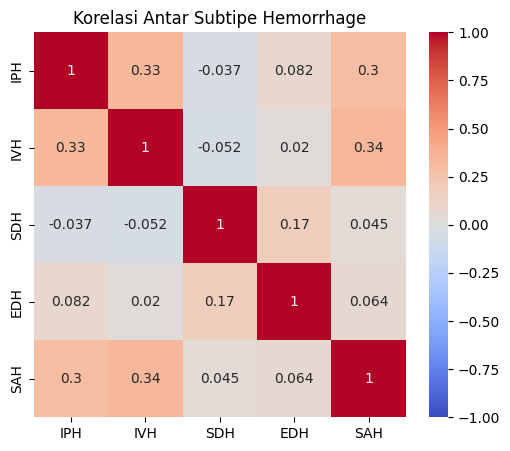

In [13]:
import seaborn as sns
import numpy as np

subtype_matrix = dataset.df[["IPH","IVH","SDH","EDH","SAH"]]

corr_matrix = subtype_matrix.corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Antar Subtipe Hemorrhage")
plt.show()


## 7. Definisi Eksperimen

Kelas `ExperimentBuilder` mendefinisikan 6 eksperimen klasifikasi biner berdasarkan jenis ICH: `any_ich`, `IPH`, `IVH`, `SDH`, `EDH`, `SAH`.

In [14]:
class ExperimentBuilder:
    
    def __init__(self, df):
        self.df = df.copy()
    
    def any_ich(self):
        df = self.df.copy()
        df["label"] = df["Any_ICH"]
        return df
    
    def subtype_vs_normal(self, subtype):
        
        positive = self.df[self.df[subtype] == 1].copy()
        
        negative = self.df[
            (self.df[["IPH","IVH","SDH","EDH","SAH"]].sum(axis=1) == 0)
        ].copy()
        
        df = pd.concat([positive, negative], ignore_index=True)
        df["label"] = df[subtype]
        
        return df.reset_index(drop=True)


builder = ExperimentBuilder(dataset.df)

experiments = {
    "any_ich": builder.any_ich(),
    "iph": builder.subtype_vs_normal("IPH"),
    "sdh": builder.subtype_vs_normal("SDH"),
    "sah": builder.subtype_vs_normal("SAH")
}


## 8. Distribusi Kelas per Eksperimen

Menampilkan jumlah sampel positif/negatif per eksperimen dan visualisasi bar chart perbandingannya.

In [15]:
print("\nDistribusi kelas per eksperimen:")

for name, df_exp in experiments.items():
    pos = df_exp["label"].sum()
    neg = len(df_exp) - pos
    
    print(f"\n{name.upper()}")
    print("Total:", len(df_exp))
    print("Positif:", pos)
    print("Normal:", neg)



Distribusi kelas per eksperimen:

ANY_ICH
Total: 473
Positif: 191
Normal: 282

IPH
Total: 411
Positif: 129
Normal: 282

SDH
Total: 331
Positif: 49
Normal: 282

SAH
Total: 339
Positif: 57
Normal: 282


### Bar Chart Distribusi Kelas

Visualisasi perbandingan jumlah positif vs negatif untuk semua eksperimen.

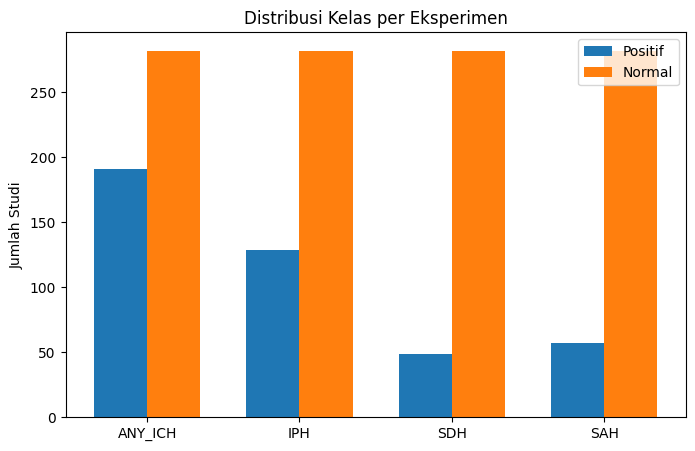

In [16]:
import numpy as np

labels_plot = []
positives = []
negatives = []

for name, df_exp in experiments.items():
    labels_plot.append(name.upper())
    positives.append(df_exp["label"].sum())
    negatives.append(len(df_exp) - df_exp["label"].sum())

x = np.arange(len(labels_plot))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, positives, width, label="Positif")
plt.bar(x + width/2, negatives, width, label="Normal")

plt.xticks(x, labels_plot)
plt.ylabel("Jumlah Studi")
plt.title("Distribusi Kelas per Eksperimen")
plt.legend()
plt.show()


## 9. Stratified Split (70 / 15 / 15)

Kelas `DataSplitter` membagi data secara stratified di level pasien: 70% train, 15% val, 15% test. Splits disimpan per eksperimen.

In [17]:
from sklearn.model_selection import train_test_split

class DataSplitter:
    
    def __init__(self, seed=42):
        self.seed = seed
    
    def split(self, df):
        
        train_df, temp_df = train_test_split(
            df,
            test_size=0.30,
            stratify=df["label"],
            random_state=self.seed
        )
        
        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df["label"],
            random_state=self.seed
        )
        
        return train_df, val_df, test_df


splitter = DataSplitter(seed=42)

splits = {}

for name, df_exp in experiments.items():
    
    train_df, val_df, test_df = splitter.split(df_exp)
    
    splits[name] = {
        "train": train_df,
        "val": val_df,
        "test": test_df
    }
    
    print(f"\n{name.upper()}")
    print("Train:", len(train_df))
    print("Val:", len(val_df))
    print("Test:", len(test_df))



ANY_ICH
Train: 331
Val: 71
Test: 71

IPH
Train: 287
Val: 62
Test: 62

SDH
Train: 231
Val: 50
Test: 50

SAH
Train: 237
Val: 51
Test: 51


### Simpan Splits

Menyimpan hasil split train/val/test ke file `.pkl` untuk digunakan kembali.

In [18]:
splits_path = os.path.join(save_dir, "cq500_splits.pkl")

with open(splits_path, "wb") as f:
    pickle.dump(splits, f)

print("✓ Splits disimpan di:", splits_path)
print("Ukuran file (MB):", round(os.path.getsize(splits_path)/1e6, 2))

✓ Splits disimpan di: /kaggle/working/cache/cq500_splits.pkl
Ukuran file (MB): 12.57


### (Diarsipkan) Load Splits

Blok kode load splits yang dikomentari — aktifkan jika splits sudah tersedia.

In [19]:
# with open("/kaggle/input/your-cache-dataset/splits.pkl", "rb") as f:
#     splits = pickle.load(f)

# print("Splits loaded successfully")

## 10. Cek Data Leakage

Memastikan tidak ada `study_id` yang tumpang tindih antar split train/val/test, lalu menampilkan distribusi kelas per subset.

In [20]:
def check_leakage(train_df, val_df, test_df):
    
    train_ids = set(train_df["study_id"])
    val_ids = set(val_df["study_id"])
    test_ids = set(test_df["study_id"])
    
    assert len(train_ids & val_ids) == 0
    assert len(train_ids & test_ids) == 0
    assert len(val_ids & test_ids) == 0

for name, split_data in splits.items():
    check_leakage(
        split_data["train"],
        split_data["val"],
        split_data["test"]
    )

print("\n✓ Tidak ada patient overlap antar subset")



✓ Tidak ada patient overlap antar subset


### Distribusi Kelas per Split

Menampilkan jumlah positif dan total per subset (train/val/test) untuk setiap eksperimen.

In [21]:
for exp_name, split_data in splits.items():
    
    print("\n", exp_name.upper())
    
    for subset in ["train","val","test"]:
        df_subset = split_data[subset]
        pos = df_subset["label"].sum()
        total = len(df_subset)
        print(f"{subset}: Positif {pos}/{total}")



 ANY_ICH
train: Positif 134/331
val: Positif 29/71
test: Positif 28/71

 IPH
train: Positif 90/287
val: Positif 20/62
test: Positif 19/62

 SDH
train: Positif 34/231
val: Positif 8/50
test: Positif 7/50

 SAH
train: Positif 40/237
val: Positif 9/51
test: Positif 8/51


## 11. Preprocessing Pipeline

`DICOMProcessor` menerapkan brain window (WL=40, WW=80) pada citra HU. `PreprocessingPipeline` melakukan resize ke 224×224, replikasi ke 3 channel, dan normalisasi ImageNet.

In [22]:
import numpy as np
import pydicom
from pathlib import Path

class DICOMProcessor:
    
    WL = 40
    WW = 80
    
    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
    
    def read_hu(self, relative_path):
        
        dcm = pydicom.dcmread(self.dataset_path / relative_path)
        image = dcm.pixel_array.astype(np.float32)
        
        slope = getattr(dcm, "RescaleSlope", 1.0)
        intercept = getattr(dcm, "RescaleIntercept", 0.0)
        
        image = image * slope + intercept
        
        return image
    
    def brain_window(self, image):
        
        hu_min = self.WL - self.WW / 2
        hu_max = self.WL + self.WW / 2
        
        image = np.clip(image, hu_min, hu_max)
        image = (image - hu_min) / (hu_max - hu_min)
        
        return image

### Visualisasi Windowing

Membandingkan citra raw Hounsfield Unit (HU) dengan hasil brain windowing.

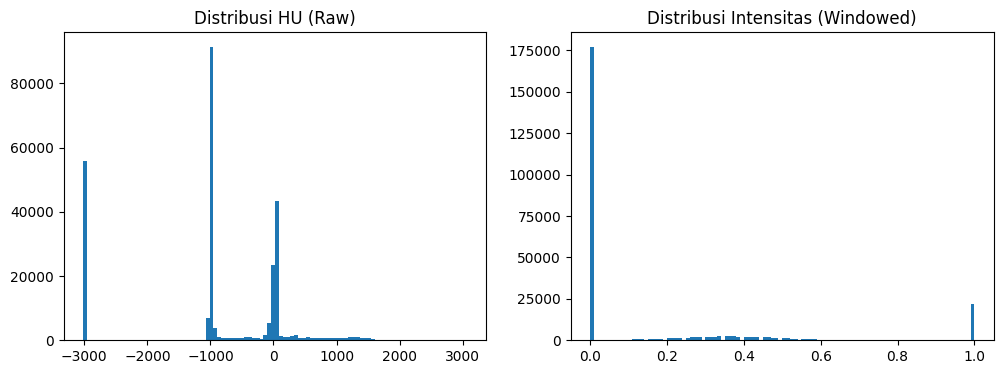

In [23]:
processor = DICOMProcessor(dataset_path)
sample_row = dataset.df.iloc[0]
sample_slice = sample_row["dicom_files"][0]

raw = processor.read_hu(sample_slice)
windowed = processor.brain_window(raw)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(raw.flatten(), bins=100)
plt.title("Distribusi HU (Raw)")

plt.subplot(1,2,2)
plt.hist(windowed.flatten(), bins=100)
plt.title("Distribusi Intensitas (Windowed)")

plt.show()


### Kelas PreprocessingPipeline

Pipeline preprocessing: resize → replikasi 3 channel (subdural/brain/bone window) → normalisasi ImageNet.

In [24]:
import cv2

class PreprocessingPipeline:
    
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    
    def __init__(self, target_size=224):
        self.target_size = target_size
    
    def resize(self, image):
        return cv2.resize(image, (self.target_size, self.target_size),
                          interpolation=cv2.INTER_LINEAR)
    
    def normalize(self, image):
        for c in range(3):
            image[c] = (image[c] - self.IMAGENET_MEAN[c]) / self.IMAGENET_STD[c]
        return image


### Fungsi Visualisasi Preprocessing

Fungsi untuk menampilkan tiap tahap preprocessing secara visual pada satu slice.

In [25]:
def visualize_preprocessing(df, processor, preprocess, 
                            study_idx=0, slice_idx=0):
    
    row = df.iloc[study_idx]
    rel_path = row["dicom_files"][slice_idx]
    
    raw = processor.read_hu(rel_path)
    windowed = processor.brain_window(raw)
    resized = preprocess.resize(windowed)
    
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    
    axes[0].imshow(raw, cmap="gray")
    axes[0].set_title("Raw HU")
    axes[0].axis("off")
    
    axes[1].imshow(windowed, cmap="gray")
    axes[1].set_title("Brain Window (WL=40, WW=80)")
    axes[1].axis("off")
    
    axes[2].imshow(resized, cmap="gray")
    axes[2].set_title("Resized 224×224")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print("Windowed Range:", windowed.min(), "to", windowed.max())


### Jalankan Visualisasi Preprocessing

Menjalankan visualisasi pada slice ke-10 dari studi pertama.

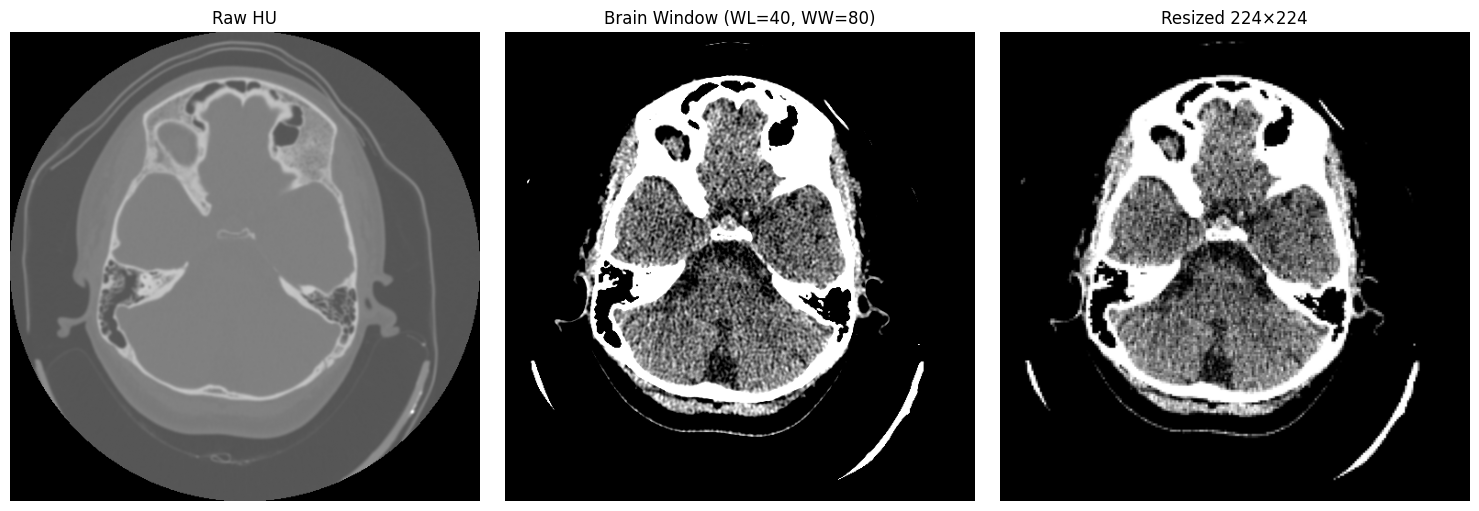

Windowed Range: 0.0 to 1.0


In [26]:
processor = DICOMProcessor(dataset_path)
preprocess = PreprocessingPipeline()

visualize_preprocessing(
    dataset.df,
    processor,
    preprocess,
    study_idx=0,
    slice_idx=10
)


### Setup Folder Cache

Membuat direktori `/kaggle/working/cache` sebagai tujuan penyimpanan file `.npy`.

In [27]:
import os
import numpy as np
from tqdm import tqdm
cache_root = "/kaggle/working/cache"
os.makedirs(cache_root, exist_ok=True)

print("Cache folder:", cache_root)


Cache folder: /kaggle/working/cache


### Fungsi Build Cache

Fungsi `build_cache` yang memproses tiap slice dan menyimpannya sebagai `.npy` di disk.

In [28]:
def build_cache(dataset_df, processor, preprocess, cache_root):
    
    total_saved = 0
    
    for _, row in tqdm(dataset_df.iterrows(), total=len(dataset_df)):
        
        study_id = row["study_id"]
        dicom_list = row["dicom_files"]
        
        study_dir = os.path.join(cache_root, study_id)
        os.makedirs(study_dir, exist_ok=True)
        
        for i, dicom_path in enumerate(dicom_list):
            
            save_path = os.path.join(study_dir, f"{i}.npy")
            
            # Skip jika sudah ada (resume-safe)
            if os.path.exists(save_path):
                continue
            
            try:
                # Phase 6 pipeline
                img = processor.read_hu(dicom_path)
                img = processor.brain_window(img)
                img = preprocess.resize(img)
                
                # simpan sebagai float16 untuk hemat storage
                np.save(save_path, img.astype(np.float16))
                
                total_saved += 1
                
            except Exception as e:
                continue
    
    print("Total cached slices:", total_saved)


## 12. Build Cache ke Disk

Fungsi `build_cache` memproses seluruh dataset dan menyimpan setiap slice sebagai file `.npy` (satu folder per study) untuk mempercepat loading saat training.

In [29]:
build_cache(dataset.df, processor, preprocess, cache_root)

100%|██████████| 473/473 [1:22:44<00:00, 10.50s/it]

Total cached slices: 102469


### Verifikasi File Cache

Menghitung total file `.npy` yang berhasil disimpan untuk memastikan tidak ada yang terlewat.

In [47]:
import glob

cached_files = glob.glob(cache_root + "/**/*.npy", recursive=True)

print("Total cached files:", len(cached_files))


Total cached files: 102469


### Kompresi Cache ke TAR

Mengompresi seluruh folder cache menjadi satu file `cache.tar` untuk kemudahan upload.

In [64]:
!tar -cf /kaggle/working/cache.tar -C /kaggle/working cache

### Pindahkan TAR ke Folder Upload

Membuat folder tujuan upload dan memindahkan `cache.tar` ke dalamnya.

In [69]:

# Buat foldernya dulu jika belum ada
!mkdir -p /kaggle/working/cq500_dataset_upload/

# Pindahkan filenya
!mv /kaggle/working/cache.tar /kaggle/working/cq500_dataset_upload/

### Pindahkan File PKL

Memindahkan file metadata dan splits (`.pkl`) ke folder upload.

In [73]:
!mv /kaggle/working/cache/*.pkl /kaggle/working/cq500_dataset_upload/

mv: cannot stat '/kaggle/working/cache/*.pkl': No such file or directory


### Verifikasi Isi Folder Upload

Menampilkan daftar dan ukuran file yang siap diupload.

In [74]:
!ls -lh /kaggle/working/cq500_dataset_upload


total 9.8G
-rw-r--r-- 1 root root 9.7G Feb 16 07:20 cache.tar
-rw-r--r-- 1 root root  12M Feb 16 05:17 cq500_labeled_metadata.pkl
-rw-r--r-- 1 root root  12M Feb 16 05:17 cq500_splits.pkl


## 13. Persiapan Folder Upload

Memindahkan `cache.tar` dan file `.pkl` ke satu folder untuk siap diupload ke Kaggle.

In [76]:
import json

USERNAME = "tsyaidfarhan"   # ← ganti dengan username Kaggle Anda

metadata = {
    "title": "CQ500 Preprocessed Cache",
    "id": f"{USERNAME}/cq500-preprocessed-cache",
    "licenses": [{"name": "CC0-1.0"}]
}

with open("/kaggle/working/cq500_dataset_upload/dataset-metadata.json", "w") as f:
    json.dump(metadata, f)

print("Metadata created.")


Metadata created.


## 14. Upload Dataset ke Kaggle API

Membuat metadata JSON (`dataset-metadata.json`) dan mengupload dataset ke Kaggle menggunakan Kaggle CLI.

In [82]:
import os
import shutil

# 1. Lokasi file yang baru saja Anda upload
source = '/kaggle/input/datasets/tsyaidfarhan/my-api/kaggle.json'

# 2. Lokasi tujuan yang diminta sistem
dest_dir = '/root/.config/kaggle'
dest_file = os.path.join(dest_dir, 'kaggle.json')

# 3. Buat folder tujuan dan pindahkan filenya
os.makedirs(dest_dir, exist_ok=True)
shutil.copy(source, dest_file)

# 4. Atur izin akses (WAJIB: API Kaggle akan error jika permission-nya terlalu terbuka)
os.chmod(dest_file, 0o600)

print("Keren! kaggle.json sudah terpasang dengan benar.")

Keren! kaggle.json sudah terpasang dengan benar.


### Upload Dataset ke Kaggle

Membuat dataset baru di Kaggle menggunakan `kaggle datasets create`.

In [83]:
!kaggle datasets create -p /kaggle/working/cq500_dataset_upload --dir-mode zip


Starting upload for file cq500_splits.pkl
100%|██████████████████████████████████████| 12.0M/12.0M [00:00<00:00, 22.6MB/s]
Upload successful: cq500_splits.pkl (12MB)
Starting upload for file cq500_labeled_metadata.pkl
100%|██████████████████████████████████████| 11.5M/11.5M [00:00<00:00, 22.9MB/s]
Upload successful: cq500_labeled_metadata.pkl (12MB)
Starting upload for file cache.tar
100%|███████████████████████████████████████| 9.70G/9.70G [01:38<00:00, 106MB/s]
Upload successful: cache.tar (10GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/tsyaidfarhan/cq500-preprocessed-cache


### Perbarui Versi Dataset

Memperbarui versi dataset yang sudah ada di Kaggle.

In [ ]:
!kaggle datasets version -p /kaggle/working/cq500_dataset_upload -m "Update cache"

## 15. Akses Dataset yang Sudah Diupload

Ekstrak cache dari Kaggle input dataset dan load splits untuk digunakan di notebook training.

In [ ]:
!tar -xf /kaggle/input/cq500-preprocessed-cache/cache.tar -C /kaggle/working/

### Load Splits dari Dataset

Memuat file `cq500_splits.pkl` dari dataset yang telah diupload.

In [ ]:
import pickle

with open(SPLITS_PATH, "rb") as f:
    splits = pickle.load(f)

### Definisi Path untuk Training

Mendefinisikan `CACHE_ROOT` dan `SPLITS_PATH` yang akan digunakan di notebook training.

In [ ]:
DATASET_NAME = "cq500-preprocessed-cache"  # ganti jika beda

DATA_ROOT = f"/kaggle/input/{DATASET_NAME}"

CACHE_ROOT = DATA_ROOT + "/cache"
SPLITS_PATH = DATA_ROOT + "/splits.pkl"

## 17. Scheduler & Kode Arsip

Fungsi learning rate scheduler dengan linear warmup + cosine decay. Blok validasi lama disimpan sebagai referensi.

In [ ]:
import numpy as np

def get_scheduler(optimizer, total_steps, warmup_steps):
    
    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


### (Diarsipkan) Kode Validasi Lama

Blok validasi patient-level yang dikomentari — dipertahankan sebagai referensi historis.

In [ ]:
# from collections import defaultdict
# from sklearn.metrics import roc_auc_score

# def validate_patient_level(model, val_loader, device, k=5):
    
#     model.eval()
    
#     from collections import defaultdict
#     slice_dict = defaultdict(list)
#     labels = {}
    
#     with torch.no_grad():
        
#         idx = 0
        
#         for images, batch_labels in val_loader:
            
#             images = images.to(device)
#             probs = torch.sigmoid(model(images)).cpu().numpy()
            
#             for i in range(len(probs)):
                
#                 study_id = val_loader.dataset.samples[idx][2]
                
#                 slice_dict[study_id].append(probs[i])
#                 labels[study_id] = batch_labels[i].item()
                
#                 idx += 1
    
#     y_true, y_pred = [], []
    
#     for sid in slice_dict:
#         topk = sorted(slice_dict[sid], reverse=True)[:k]
#         y_pred.append(np.mean(topk))
#         y_true.append(labels[sid])
    
#     return roc_auc_score(y_true, y_pred)

